# Play Store Data Analysis - Grouped Bar Chart
## Comparing Average Rating and Review Count for Top 10 App Categories

This notebook analyzes Play Store data with the following filters:
- Average rating >= 4.0
- App size >= 10M
- Last update in January
- Graph display: Only between 3PM IST to 5PM IST

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pytz
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

In [2]:
df = pd.read_csv('Play Store Data.csv')
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names    types\n")
df.dtypes

Dataset shape: (10841, 13)

Column names    types



,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [4]:
df_clean = df.copy()

df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')

df_clean['Reviews'] = pd.to_numeric(df_clean['Reviews'], errors='coerce')

def parse_size(size):
    if pd.isna(size) or size == 'Varies with device':
        return np.nan
    size = str(size).strip()
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size or 'K' in size:
        return float(size.replace('k', '').replace('K', ''))/1024
    else:
        return np.nan

df_clean['Size_MB'] = df_clean['Size'].apply(parse_size)

df_clean['Last_Updated'] = pd.to_datetime(df_clean['Last Updated'], errors='coerce')
df_clean['Update_Month'] = df_clean['Last_Updated'].dt.month

def parse_installs(installs):
    installs = str(installs).replace('+', '').replace(',', '')
    try:
        return int(installs)
    except:
        return np.nan

df_clean['Installs_Numeric'] = df_clean['Installs'].apply(parse_installs)

print("Data after preprocessing:")
df_clean[['App', 'Category', 'Rating', 'Reviews', 'Size_MB', 'Installs_Numeric', 'Update_Month']]

Data after preprocessing:


,App,Category,Rating,Reviews,Size_MB,Installs_Numeric,Update_Month
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,1.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,1.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,8.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,6.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,6.0
...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38.0,53.0,5000.0,7.0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4.0,3.6,100.0,7.0
10838,Parkinson Exercices FR,MEDICAL,NaN,3.0,9.5,1000.0,1.0
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114.0,NaN,1000.0,1.0


In [5]:
# filters:
# 1. Average rating >= 4.0
# 2. Size >= 10M
# 3. Last update in January (month = 1)

df_filtered = df_clean[
    (df_clean['Rating'] >= 4.0) &  # Rating filter
    (df_clean['Size_MB'] >= 10) &  # Size filter (>= 10M)
    (df_clean['Update_Month'] == 1)  # January filter
].copy()

print(f"Original dataset rows: {len(df_clean)}")
print(f"After filtering rows: {len(df_filtered)}")
print(f"\nCategories in filtered data: {df_filtered['Category'].nunique()}")
print(f"\nFiltered data sample:")
df_filtered[['App', 'Category', 'Rating', 'Reviews', 'Size_MB', 'Installs_Numeric']].head()

Original dataset rows: 10841
After filtering rows: 131

Categories in filtered data: 22

Filtered data sample:


,App,Category,Rating,Reviews,Size_MB,Installs_Numeric
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0
33,Easy Origami Ideas,ART_AND_DESIGN,4.2,1015.0,11.0,100000.0
44,Popsicle Sticks and Similar DIY Craft Ideas,ART_AND_DESIGN,4.2,26.0,12.0,10000.0
446,Video Caller Id,COMMUNICATION,4.2,15287.0,17.0,1000000.0
719,Monster Truck Driver & Racing,EDUCATION,4.4,748.0,51.0,1000000.0


In [8]:
# Group by category and calculate metrics
category_stats = df_filtered.groupby('Category').agg({
    'Installs_Numeric': 'sum',  # Total installs
    'Rating': 'mean',  # Average rating
    'Reviews': 'sum'  # Total reviews
}).reset_index()

category_stats.columns = ['Category', 'Total_Installs', 'Avg_Rating', 'Total_Reviews']

# Sort by total installs and get top 10
top_10_categories = category_stats.nlargest(10, 'Total_Installs')

print("Top 10 Categories by Number of Installs:")
print(top_10_categories.to_string(index=False))
print(f"\nTotal categories selected: {len(top_10_categories)}")

Top 10 Categories by Number of Installs:
       Category  Total_Installs  Avg_Rating  Total_Reviews
         FAMILY     182494820.0    4.395455      4544623.0
         SPORTS     120511000.0    4.342857      1982017.0
           GAME     115691000.0    4.313333      2397589.0
  ENTERTAINMENT      51000000.0    4.250000      1238948.0
PERSONALIZATION      15060000.0    4.475000       155996.0
    PHOTOGRAPHY      10500000.0    4.150000       563720.0
      LIFESTYLE       5071000.0    4.380000        42809.0
      EDUCATION       2000000.0    4.400000        57645.0
       SHOPPING       2000000.0    4.200000        19950.0
          TOOLS       1010000.0    4.200000         8010.0

Total categories selected: 10


In [9]:
# Get current time in IST (Indian Standard Time)
ist = pytz.timezone('Asia/Kolkata')
current_time_ist = datetime.now(ist)
current_hour = current_time_ist.hour
current_minute = current_time_ist.minute

# Check if current time is between 3PM (15:00) and 5PM (17:00) IST
is_display_time = 15 <= current_hour < 17  # 3PM to 5PM

print(f"Current Time (IST): {current_time_ist.strftime('%H:%M:%S')}")
print(f"Display Graph (3PM-5PM IST): {is_display_time}")

if is_display_time:
    print("✓ Graph will be displayed (current time is between 3PM and 5PM IST)")
else:
    print("✗ Graph will NOT be displayed (current time is outside 3PM-5PM IST window)")

Current Time (IST): 15:25:04
Display Graph (3PM-5PM IST): True
✓ Graph will be displayed (current time is between 3PM and 5PM IST)


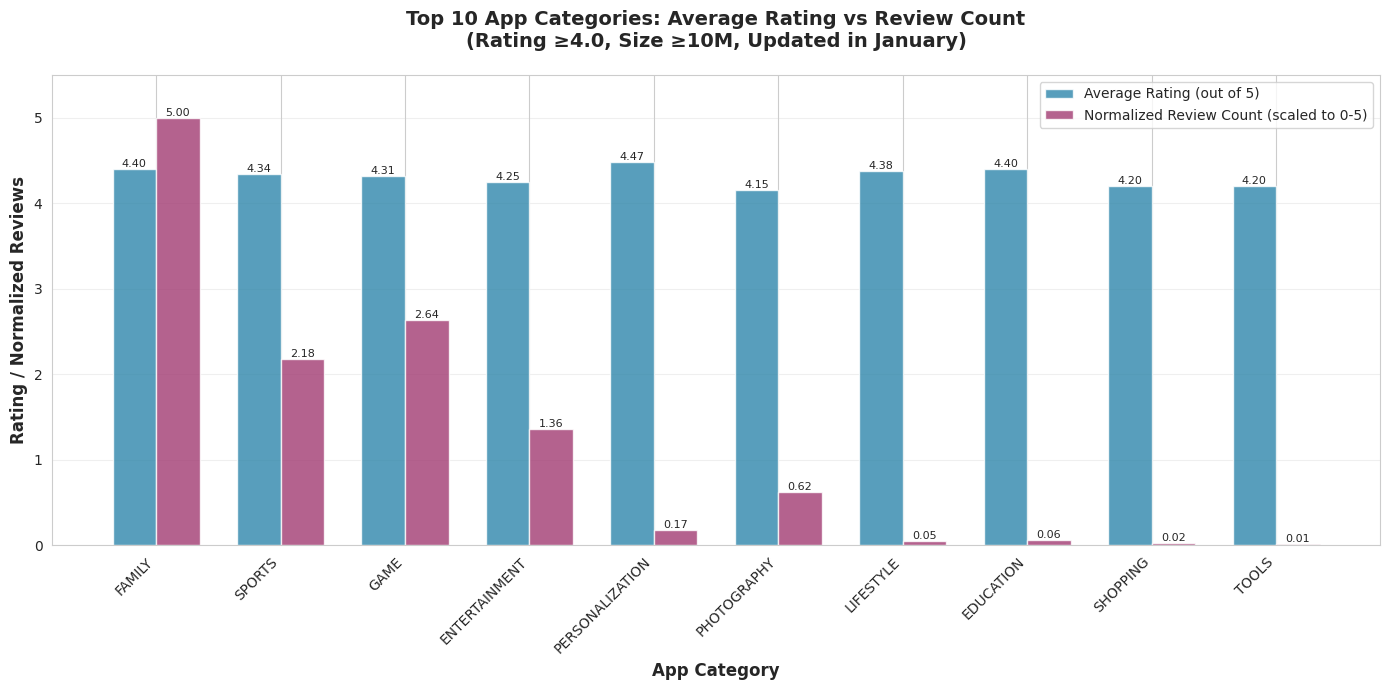


✓ Chart displayed successfully!


In [10]:
# Only display the chart if current time is between 3PM and 5PM IST
if is_display_time:
    # Normalize Review count for better visualization (scale to 0-5 range for comparison)
    max_reviews = top_10_categories['Total_Reviews'].max()
    top_10_categories['Normalized_Reviews'] = (top_10_categories['Total_Reviews'] / max_reviews) * 5

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(14, 7))

    # Set the width of bars and positions
    x = np.arange(len(top_10_categories))
    width = 0.35

    # Create bars
    bars1 = ax.bar(x - width/2, top_10_categories['Avg_Rating'], width,
                    label='Average Rating (out of 5)', color='#2E86AB', alpha=0.8)
    bars2 = ax.bar(x + width/2, top_10_categories['Normalized_Reviews'], width,
                    label='Normalized Review Count (scaled to 0-5)', color='#A23B72', alpha=0.8)

    # Customize the chart
    ax.set_xlabel('App Category', fontsize=12, fontweight='bold')
    ax.set_ylabel('Rating / Normalized Reviews', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 App Categories: Average Rating vs Review Count\n(Rating ≥4.0, Size ≥10M, Updated in January)',
                  fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(top_10_categories['Category'], rotation=45, ha='right')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 5.5)

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

    print("\n✓ Chart displayed successfully!")
else:
    print("\n" + "="*60)
    print("GRAPH NOT DISPLAYED")
    print("="*60)
    print(f"Current Time: {current_time_ist.strftime('%H:%M:%S %Z')}")
    print(f"Display Window: 15:00 - 17:00 IST (3PM - 5PM)")
    print("\nThis graph is only available during 3PM to 5PM IST.")
    print("Please check back during this time window to see the visualization.")
    print("="*60)

In [11]:
print("\n" + "="*70)
print("SUMMARY STATISTICS - TOP 10 CATEGORIES")
print("="*70)
print(f"\nFilters Applied:")
print(f"  • Average Rating: ≥ 4.0")
print(f"  • App Size: ≥ 10M")
print(f"  • Last Update: January (any year)")

display_df = top_10_categories[['Category', 'Total_Installs', 'Avg_Rating', 'Total_Reviews']].copy()
display_df['Total_Installs'] = display_df['Total_Installs'].apply(lambda x: f"{x:,.0f}")
display_df['Avg_Rating'] = display_df['Avg_Rating'].apply(lambda x: f"{x:.2f}")
display_df['Total_Reviews'] = display_df['Total_Reviews'].apply(lambda x: f"{x:,.0f}")

print("\n")
print(display_df.to_string(index=False))
print("\n" + "="*70)


SUMMARY STATISTICS - TOP 10 CATEGORIES

Filters Applied:
  • Average Rating: ≥ 4.0
  • App Size: ≥ 10M
  • Last Update: January (any year)


       Category Total_Installs Avg_Rating Total_Reviews
         FAMILY    182,494,820       4.40     4,544,623
         SPORTS    120,511,000       4.34     1,982,017
           GAME    115,691,000       4.31     2,397,589
  ENTERTAINMENT     51,000,000       4.25     1,238,948
PERSONALIZATION     15,060,000       4.47       155,996
    PHOTOGRAPHY     10,500,000       4.15       563,720
      LIFESTYLE      5,071,000       4.38        42,809
      EDUCATION      2,000,000       4.40        57,645
       SHOPPING      2,000,000       4.20        19,950
          TOOLS      1,010,000       4.20         8,010



In [12]:
# Additional insights
print("\nADDITIONAL INSIGHTS:")
print("="*70)

print(f"\n1. Highest Rated Category:")
highest_rated = top_10_categories.loc[top_10_categories['Avg_Rating'].idxmax()]
print(f"   {highest_rated['Category']}: {highest_rated['Avg_Rating']:.2f} stars")

print(f"\n2. Most Reviewed Category:")
most_reviewed = top_10_categories.loc[top_10_categories['Total_Reviews'].idxmax()]
print(f"   {most_reviewed['Category']}: {most_reviewed['Total_Reviews']:,.0f} total reviews")

print(f"\n3. Highest Installs:")
highest_installs = top_10_categories.loc[top_10_categories['Total_Installs'].idxmax()]
print(f"   {highest_installs['Category']}: {highest_installs['Total_Installs']:,.0f} installs")

print(f"\n4. Average Rating Across Top 10 Categories: {top_10_categories['Avg_Rating'].mean():.2f} stars")
print(f"\n5. Total Reviews Across Top 10 Categories: {top_10_categories['Total_Reviews'].sum():,.0f}")
print(f"\n6. Total Installs Across Top 10 Categories: {top_10_categories['Total_Installs'].sum():,.0f}")


ADDITIONAL INSIGHTS:

1. Highest Rated Category:
   PERSONALIZATION: 4.47 stars

2. Most Reviewed Category:
   FAMILY: 4,544,623 total reviews

3. Highest Installs:
   FAMILY: 182,494,820 installs

4. Average Rating Across Top 10 Categories: 4.31 stars

5. Total Reviews Across Top 10 Categories: 11,011,307

6. Total Installs Across Top 10 Categories: 505,337,820
